In [97]:
# %pip install scikit-learn

In [98]:
# 1. 라이브러리 불러오기
import pandas as pd
import re
import html
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [99]:
# 1. 데이터 로드

def load_data(file_path):
    df = pd.read_csv(file_path)
    return df

df = load_data('../data/Womens Clothing E-Commerce Reviews.csv')

df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [100]:
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')

In [101]:
# 3. 텍스트 전처리

def clean_text(text):

    # 리뷰 텍스트 정제
    # html 코드 제거
    # 소문자 변환
    # 특수문자 제거
    # 공백 정리

    text = str(text)
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ' , text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [102]:
# 리뷰 텍스트
# text_col = 'Review Text'

# 결측치 제거 (리뷰가 존재 하지 않는 데이터들)
# df = df.dropna(subset=[text_col])

def process_data(df, text_col = 'Review Text'):
    # 전체 데이터 전처리
    # 결측치 제거
    # 텍스트 정제
    # 짧은 리뷰 제거

    # 결측치 제거
    df = df.dropna(subset = [text_col])

    # 텍스트 정제
    df['cleaned_text'] = df[text_col].apply(clean_text)

    # 짧은 리뷰 제거
    df = df[df['cleaned_text'].str.len() > 5]

    print("전처리 후 데이터 크기:" , df.shape)
    print("\n정제된 텍스트 샘플:")
    print(df[['Review Text', 'cleaned_text']].head())

    return df

df = process_data(df)

print(df.head())


전처리 후 데이터 크기: (22641, 12)

정제된 텍스트 샘플:
                                         Review Text  \
0  Absolutely wonderful - silky and sexy and comf...   
1  Love this dress!  it's sooo pretty.  i happene...   
2  I had such high hopes for this dress and reall...   
3  I love, love, love this jumpsuit. it's fun, fl...   
4  This shirt is very flattering to all due to th...   

                                        cleaned_text  
0  absolutely wonderful silky and sexy and comfor...  
1  love this dress it s sooo pretty i happened to...  
2  i had such high hopes for this dress and reall...  
3  i love love love this jumpsuit it s fun flirty...  
4  this shirt is very flattering to all due to th...  
   Unnamed: 0  Clothing ID  Age                    Title  \
0           0          767   33                      NaN   
1           1         1080   34                      NaN   
2           2         1077   60  Some major design flaws   
3           3         1049   50         My favorite bu

In [103]:
# 1. 이탈 기준
# 이탈 위험 사용자는 다음 조건 중 하나 이상을 만족하는 사용자로 정의.
# Rating<=2 or Recommend = 0
# 이때, 평점이 높은데 추천을 안하거나 / 평점은 낮은데 추천을 하는 사용자가 존재할 수 있음.
# ===============================================================================
# 2. 연령 그룹
# 10~20대/30~40대/50~60대/70대 이상
# ===============================================================================
# 3. 키워드 분석
# 긍정/부정 단어 기반으로 CRM 분석 => 이탈 위험 사용자 그룹에서 자주 등장하는 키워드 분석.

In [104]:
# 4. 사용자 유형 분류
def classify_user(row):
    # 정상 사용자
    if row['Rating'] >= 4 and row['Recommended IND'] == 1:
        return 'Stable' 
    # 이탈 사용자
    elif row['Rating'] <= 2 and row['Recommended IND'] == 0:
        return 'Churn' 
    #잠재 이탈
    elif row['Rating'] >= 4 and row['Recommended IND'] == 0:
        return 'Hidden Churn'
    #모순 사용자
    elif row['Rating'] <= 2 and row['Recommended IND'] == 1:
        return 'Inconsistent'
    else:
        return 'Neutral'

In [105]:
# 사용자 유형 컬럼 추가
def add_user_type(df):
    
    df['user_type'] = df.apply(classify_user, axis=1)

    print('\n 사용자 유형 분포:')
    print(df['user_type'].value_counts())

    return df

df = add_user_type(df)

df.head()


 사용자 유형 분포:
user_type
Stable          17261
Neutral          2823
Churn            2261
Hidden Churn      187
Inconsistent      109
Name: count, dtype: int64


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,cleaned_text,user_type
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,absolutely wonderful silky and sexy and comfor...,Stable
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,love this dress it s sooo pretty i happened to...,Stable
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,i had such high hopes for this dress and reall...,Neutral
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,i love love love this jumpsuit it s fun flirty...,Stable
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,this shirt is very flattering to all due to th...,Stable


In [106]:
# 5. 키워드 기반 분석

# 기본 불용어 리스트
NEGATIVE_WORDS = [
    'bad','poor','small','tight','return','disappointed',
    'cheap','problem','issue','wrong','uncomfortable',
    'fit','size','too','not'
]

# 특정 단어 리스트 기반으로 빈도 높은 키워드 추출
def extract_keywords(df, label):

    print("\n" + "=" *50)
    print(f"{label} 키워드 분석 시작")
    print("="*50)

    print("데이터 개수", len(df))
    print("사용 키워드:" , NEGATIVE_WORDS)

    # 데이터 없으면 바로 종료
    if len(df) == 0:
        print("데이터 없음")
        return []
    
    words = " ".join(df['cleaned_text']).split()
    filtered_words = [w for w in words if w in NEGATIVE_WORDS]

    # 빈도 계산
    keyword_counts = Counter(filtered_words).most_common(10)
    
    print("\n 키워드 결과:")
    for word, count in keyword_counts:
        print(f"{word}: {count}")  
        
    return keyword_counts


In [107]:
# 6. 이탈 영향 분석

def analyze_keyword_impact(df):

    # "특정 키워드 포함 시 이탈률 변화 분석"

    print("\n 키워드 영향 분석 시작")

    # 전체 이탈률
    total_churn_rate = (df['user_type'] == 'Churn').mean()
    print(f"\n 전체 이탈률: {total_churn_rate:.2f}")

    # 주요 키워드

    target_words = ['size', 'fit', 'small']

    for word in target_words:
        subset = df[df['cleaned_text'].str.contains(word, na = False)]

        churn_rate = (subset['user_type'] == 'Churn').mean()

        print(f"\n[{word}]")
        print(f"- 데이터 수: {len(subset)}")
        print(f"- 이탈률: {churn_rate:.2f}")
        print(f"- 전체 대비: {(churn_rate / total_churn_rate):.2f}배")

In [108]:
# 7. 시각화

def plot_keywords(keyword_data, title): 

    # "키워드 빈도 시각화"

    if not keyword_data:
        print(f"{title} 데이터 없음")
        return

    df_plot = pd.DataFrame(keyword_data, columns=['word', 'count'])

    print(f"\n{title} 시각화")
    print(df_plot)

    plt.figure(figsize=(10,5))
    sns.barplot(data=df_plot, x='word', y='count')

    plt.title(title)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

In [109]:
# 8. 머신러닝 기반 이탈 예측

def churn_prediction_model(df):

    # "리뷰 텍스트 기반 이탈 예측 모델"

    print("\n 머신러닝 모델 시작")

    # 이탈 여부 라벨 생성
    df['churn_label'] = (df['user_type'] == 'Churn').astype(int)

    # 텍스트 -> 숫자 변환
    vectorizer = CountVectorizer(max_features=1000, stop_words='english')
    X = vectorizer.fit_transform(df['cleaned_text'])
    y = df['churn_label']

    print("데이터 벡터화 완료:", X.shape)

    # 데이터 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 모델 학습
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # 정확도
    accuracy = model.score(X_test, y_test)
    print(f"\n 모델 정확도: {accuracy:.2f}")

    # 영향력 높은 키워드 
    feature_names = vectorizer.get_feature_names_out()
    coefficients = model.coef_[0]

    top_words = sorted(
        zip(feature_names, coefficients),
        key = lambda x: x[1],
        reverse=True
    )[:10]

    print("\n 이탈 영향 높은 키워드 TOP 10")

    for word, coef in top_words:
        print(f"{word}: {coef:.4f}")

In [110]:
# 9. 실행 파이프라인

def run_analysis(file_path):

    print("분석 시작")

    # 1. 데이터 로드
    df = load_data(file_path='../data/Womens Clothing E-Commerce Reviews.csv')

    # 2. 전처리
    df = process_data(df)

    # 3. 사용자 분류
    df = add_user_type(df)

    # 4. 키워드 분석
    print("\n" + "="*60)
    print("📊 키워드 분석 시작")
    print("="*60)

    # Churn
    churn_df = df[df['user_type'] == 'Churn']
    churn_keywords = extract_keywords(churn_df, "Churn 사용자")

    # Hidden Churn
    hidden_df = df[df['user_type'] == 'Hidden Churn']
    hidden_keywords = extract_keywords(hidden_df, "Hidden Churn 사용자")

    plot_keywords(churn_keywords, "Churn Keywords")
    plot_keywords(hidden_keywords, "Hidden Churn Keywords")

    # 5. 이탈 영향 분석
    analyze_keyword_impact(df)

    # 6. 머신러닝
    churn_prediction_model(df)



분석 시작
전처리 후 데이터 크기: (22641, 12)

정제된 텍스트 샘플:
                                         Review Text  \
0  Absolutely wonderful - silky and sexy and comf...   
1  Love this dress!  it's sooo pretty.  i happene...   
2  I had such high hopes for this dress and reall...   
3  I love, love, love this jumpsuit. it's fun, fl...   
4  This shirt is very flattering to all due to th...   

                                        cleaned_text  
0  absolutely wonderful silky and sexy and comfor...  
1  love this dress it s sooo pretty i happened to...  
2  i had such high hopes for this dress and reall...  
3  i love love love this jumpsuit it s fun flirty...  
4  this shirt is very flattering to all due to th...  

 사용자 유형 분포:
user_type
Stable          17261
Neutral          2823
Churn            2261
Hidden Churn      187
Inconsistent      109
Name: count, dtype: int64

📊 키워드 분석 시작

Churn 사용자 키워드 분석 시작
데이터 개수 2261
사용 키워드: ['bad', 'poor', 'small', 'tight', 'return', 'disappointed', 'cheap', 'probl

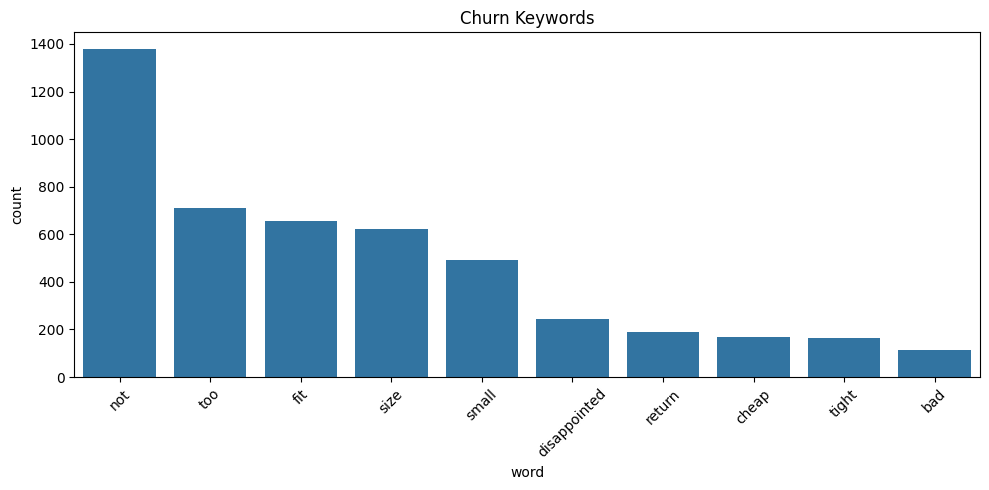


Hidden Churn Keywords 시각화
           word  count
0           not    109
1           fit     80
2          size     79
3           too     72
4         small     42
5        return     24
6         tight     15
7  disappointed     11
8       problem      6
9           bad      4


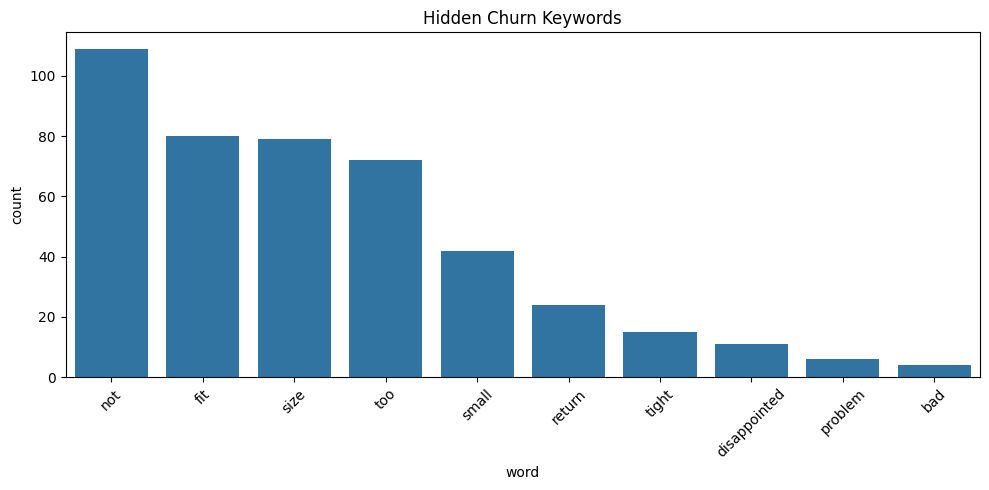


 키워드 영향 분석 시작

 전체 이탈률: 0.10

[size]
- 데이터 수: 7388
- 이탈률: 0.08
- 전체 대비: 0.79배

[fit]
- 데이터 수: 9281
- 이탈률: 0.08
- 전체 대비: 0.75배

[small]
- 데이터 수: 4283
- 이탈률: 0.11
- 전체 대비: 1.08배

 머신러닝 모델 시작
데이터 벡터화 완료: (22641, 1000)

 모델 정확도: 0.91

 이탈 영향 높은 키워드 TOP 10
awful: 1.8945
bag: 1.6873
poor: 1.4621
money: 1.4440
terrible: 1.3489
shapeless: 1.3317
rack: 1.2648
unflattering: 1.1713
life: 1.1429
tent: 1.1405


In [111]:
if __name__ == "__main__":
    run_analysis('../data/Womens Clothing E-Commerce Reviews.csv')

In [112]:
# 해석
# churn(이탈 사용자) => 전반적으로 상품에 대한 만족도가 낮으며, 특히 사이즈 및 핏 문제와 함께 품질에 대한 불만이 주요 이탈 요인
# 품질+사이즈+전반적 불만

# hidden(잠재적 이탈) => 전반적인 만족도는 높지만, 사이즈 및 착용감과 관련된 반복적인 불편 요소가 존재하여 추천으로 이어지지 않은 사용자군으로 판단.
# 대부분 만족 but 사이즈 문제나 착용감 문제

# 이탈 사용자는 전반적인 품질 불만이 주요 원인, 잠재 이탈 사용자는 특정 요소들이 불편의 주요 요인으로 나타남.


In [113]:
# Churn 대상
# 품질에 대한 불만과 실망 경험이 주요 요인 / 리뷰 기반 신뢰도 강화 및 품질 개선 전략
# ============================================================================

# Hidden Churn 대상
# 사이즈와 핏 관련 불편이 지속적으로 나타남 / 개인화된 사이즈 추천 및 가이드 제공을 통해 사용자 만족도 개선

In [114]:
# 이탈 사용자와 잠재적 이탈 사용자 모두 size, fit, small 등의 키워드가 공통적으로 높은 빈도
# 사이즈 관련 문제가 주요 요인.